# Beyond BLAST: generalized window functions

In [11]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

  Activating project at `~/Desktop/cosmo/blast_code`
  No Changes to `~/Desktop/cosmo/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/blast_code/Manifest.toml`


Main.blast_tutorials

In [12]:
include("blast_code/src/new_funcs.jl")

compute_T̃_beyond (generic function with 1 method)

In [13]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LoopVectorization
using LinearAlgebra
using Revise
using SpecialFunctions
using .Blast
using .blast_tutorials

In [191]:
ℓ = Blast.ℓ
n_chi = 6 # number of comoving "bins"
x_min = 26 # minimum comoving distance
x_max = 7000 # maximum comoving distance
χ = LinRange(x_min, x_max, n_chi) # array of comoving distances
R = chebpoints(n_chi, -1, 1) # array of ratios
R = reverse(R[R.>0])
nR = length(R) # number of ratios R
kmax = 200/13 # maximum wavenumber (small scales)
kmin = 2.5/x_max # minimum wavenumber (large scales)
n_cheb = 50 # number of Chebyshev nodes 
β = 2 # exponent depending on the probe
      # 0 for Galaxy - Shear, 
      # 2 for Galaxy - Galaxy, 
      # -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
# Define k' and k'' on Chebyshev grid
kp = kpp = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)) # wavenumbers k' and k''
N = 2^(10)+1 # number of integration points
#println(sizeof(k_cheb))
#println(sizeof(kp))

1025

In [192]:
using Dates
# Create timestamped folder for outputs
timestamp = Dates.format(now(), "yyyymmdd_HHMMSS")
output_dir = "run_$(timestamp)"
plots_dir = joinpath(output_dir, "plots")
mkpath(output_dir)
mkpath(plots_dir)
println("Output directory: $output_dir")
println("Plots directory: $plots_dir")
# Function to save plots
function save_plot(p, name::String)
    filepath = joinpath(plots_dir, "$(name).png")
    savefig(p, filepath)
    println("Saved: $filepath")
    return p
end
# Save parameters to file
params_dict = Dict(
    "ℓ" => ℓ,
    "n_chi" => n_chi,
    "x_min" => x_min,
    "x_max" => x_max,
    "nR" => nR,
    "kmax" => kmax,
    "kmin" => kmin,
    "n_cheb" => n_cheb,
    "β" => β,
    "k'" => kp,
    "k''" => kpp,
    "N" => N,
    "timestamp" => timestamp
)
# Save as txt
open(joinpath(output_dir, "parameters.txt"), "w") do f
    write(f, "Beyond BLAST Run Parameters\n")
    write(f, "==========================\n")
    write(f, "Timestamp: $timestamp\n\n")
    write(f, "ℓ array length: $(length(ℓ))\n")
    write(f, "n_chi: $n_chi\n")
    write(f, "x_min: $x_min\n")
    write(f, "x_max: $x_max\n")
    write(f, "nR: $nR\n")
    write(f, "kmax: $kmax\n")
    write(f, "kmin: $kmin\n")
    write(f, "n_cheb: $n_cheb\n")
    write(f, "β: $β\n")
    write(f, "k': $kp\n")
    write(f, "k'': $kpp\n")
    write(f, "N: $N\n")
end
println("Parameters saved to: $(joinpath(output_dir, "parameters.txt"))")

Output directory: run_20260515_161152
Plots directory: run_20260515_161152/plots
Parameters saved to: run_20260515_161152/parameters.txt


In [193]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array of background redshifts
χ_b = npzread("blast_code/data/background/chi.npy") # array of background comoving distances 
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # an array of z(\chi)

In [194]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

In [195]:
#Interpolating the power spectrum
#Linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))

InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables
power_spectrum(k, χ1, χ2) = @. sqrt(1^InterpPmm(z_of_χ(χ1),log1(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

In [196]:
# Compute T̃ for each ℓ value with new function and time it
computation_time = @elapsed begin
    T_LL_full = zeros(length(ℓ), length(χ), length(R), length(kp), length(kpp), n_cheb + 1)
    T_CL_full = zeros(length(ℓ), length(χ), length(R), length(kp), length(kpp), n_cheb + 1)
    T_CC_full = zeros(length(ℓ), length(χ), length(R), length(kp), length(kpp), n_cheb + 1)

    for i in eachindex(ℓ)
        T_LL_full[i,:,:,:,:,:], T_CL_full[i,:,:,:,:,:], T_CC_full[i,:,:,:,:,:] = compute_T̃_beyond(ℓ[i], χ, R, kp, kpp, kmin, kmax; n_cheb, N)
        println("step ", i, " completed")
    end

    # Sum over k' and k'' dimensions (dims 4 and 5)
    # this takes the 5D representation and returns the object in 3D, after marginalizing (integrating) over k' and k''.
    global T_LL = dropdims(sum(T_LL_full, dims=(4,5)), dims=(4,5))
    global T_CL = dropdims(sum(T_CL_full, dims=(4,5)), dims=(4,5))
    global T_CC = dropdims(sum(T_CC_full, dims=(4,5)), dims=(4,5))
end

# Append computation time to parameters file
open(joinpath(output_dir, "parameters.txt"), "a") do f
    write(f, "\nComputation Time:\n")
    write(f, "================\n")
    write(f, "T̃ computation time: $(computation_time) seconds ($(computation_time/60) minutes)\n")
end
println("Computation took: $(computation_time) seconds")

step 1 completed
step 2 completed
step 3 completed
step 4 completed
step 5 completed
step 6 completed
step 7 completed
step 8 completed
step 9 completed
step 10 completed
step 11 completed
step 12 completed
step 13 completed
step 14 completed
step 15 completed
step 16 completed
step 17 completed
step 18 completed
step 19 completed
step 20 completed
step 21 completed
step 22 completed
Computation took: 176.075933 seconds


In [197]:
#Shapes are (length(ℓ), n_chi, nR, n_cheb+1)
print("Shape of the computed T̃_LL: ", size(T_LL), "\n")
print("Shape of the computed T̃_CL: ", size(T_CL), "\n")
print("Shape of the computed T̃_CC: ", size(T_CC), "\n")

Shape of the computed T̃_LL: (22, 6, 3, 51)
Shape of the computed T̃_CL: (22, 6, 3, 51)
Shape of the computed T̃_CC: (22, 6, 3, 51)


In [198]:
cosmo = Blast.FlatΛCDM()
z_range = z_of_χ.(χ)
bgrid = Blast.CosmologicalGrid(z_range = z_range)
bg = Blast.BackgroundQuantities(Hz_array = zeros(length(z_range)), χz_array = Array(χ));

In [199]:
cheb_coeff = zeros(n_chi, nR, n_cheb + 1)
vals = power_spectrum.(10 .^ k_cheb, χ[1], χ[1] * R[1])
plan = Blast.plan_fft(vals)

for i in 1:nR
    for j in 1:n_chi
        vals = power_spectrum.(10 .^ k_cheb, χ[j], χ[j] * R[i])
        cheb_coeff[j, i, :] = Blast.fast_chebcoefs(vals, plan)
    end
end
println("size of the chebyshev coefficients term")
println(size(cheb_coeff))
println("size of the computed T̃ term")
println(size(T_LL))

LoadError: UndefVarError: `log1` not defined

In [ ]:
# Continue as before with w_ell_tullio
w_LL = Blast.w_ell_tullio(cheb_coeff, T_LL)
w_CL = Blast.w_ell_tullio(cheb_coeff, T_CL)
w_CC = Blast.w_ell_tullio(cheb_coeff, T_CC);

Saved: run_20260515_155643/plots/wLL_ell2.png


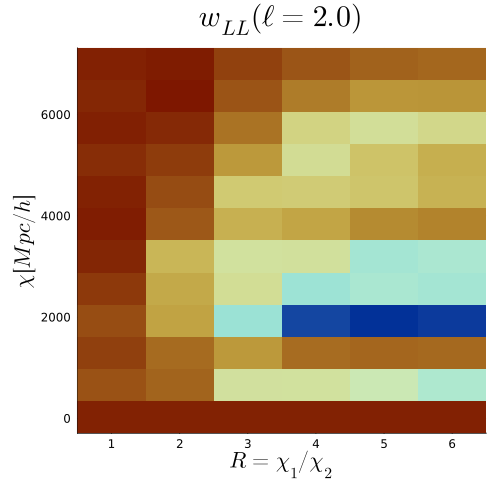

In [ ]:
p1 = heatmap(1:nR, χ, w_LL[1,:,:]./maximum(w_LL[1,:,:]), size = (500,500), title=L"w_{LL}(ℓ=2.0)", 
    c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)
save_plot(p1, "wLL_ell2")

# plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
# annotate!(11, 7300, text(L"R=0.5",14), :black)

# plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
# annotate!(23, 7300, text(L"R=0.8",14), :black)

# plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing,axis=([], false), size = (500,500)) 
# annotate!(34, 7400, text(L"R=0.9",14), :black)

Saved: run_20260515_155643/plots/wLL_ell211.png


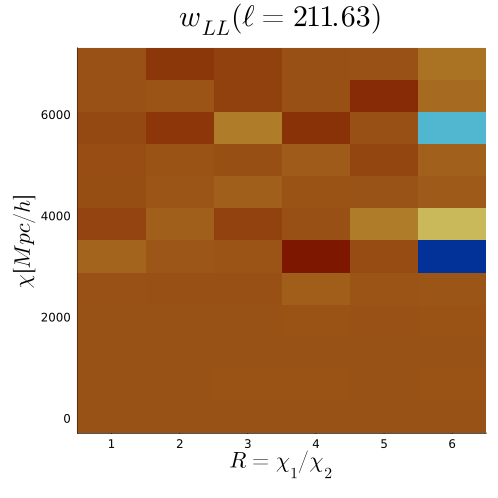

In [ ]:
p2 = heatmap(1:nR, χ, w_LL[22,:,:]./maximum(w_LL[22,:,:]), size = (500,500), title=L"w_{LL}(ℓ=211.63)",
    legend = :none, c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]",
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)
save_plot(p2, "wLL_ell211")

# plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
# annotate!(11, 7300, text(L"R=0.5",14), :black)

# plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
# annotate!(23, 7300, text(L"R=0.8",14), :black)

# plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5",axis=([], false), size = (500,500)) 
# annotate!(34, 7400, text(L"R=0.9",14), :black)

In [ ]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")

Dict{String, Array{Float64}} with 4 entries:
  "dNdz_cl" => [9.51877e-8 1.11093e-13 … 5.97529e-61 6.25179e-67; 1.246e-7 1.56…
  "z_sh"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…
  "dNdz_sh" => [0.106801 1.52148e-9 … 6.04656e-24 7.57113e-34; 0.111443 1.76706…
  "z_cl"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…

In [ ]:
GalKernels = Blast.GalaxyKernel(10, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_cl"]',  n5k_bins["z_cl"], GalKernels, bgrid, bg, cosmo)

In [ ]:
ShearKernels = Blast.ShearKernel(4, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_sh"]', n5k_bins["z_sh"], ShearKernels, bgrid, bg, cosmo)

In [ ]:
#Loading the N5K pre-computed kernel to check that they match!
W = npzread("blast_code/data/kernels_fullwidth.npz")

Dict{String, Array{Float64}} with 6 entries:
  "chi_cl"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_sh" => [6.04145e-7 7.78856e-7 … 0.0 0.0; 6.14932e-7 7.9704e-7 … 0.0 …
  "z_sh"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…
  "chi_sh"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_cl" => [0.0 1.02182e-10 … 0.0 0.0; 0.0 9.54391e-17 … 0.0 0.0; … ; 0.…
  "z_cl"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…

Saved: run_20260515_155643/plots/clustering_kernels.png


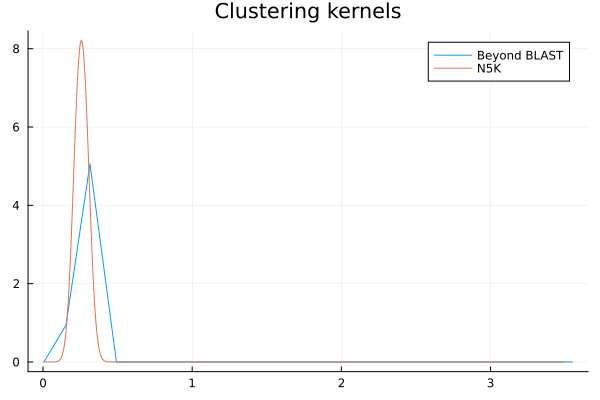

In [ ]:
i_bin = 1

interp = DataInterpolations.AkimaInterpolation( W["kernels_cl"][i_bin,:], W["z_cl"], extrapolation = ExtrapolationType.Linear)
intn, _ = quadgk(x -> interp.(x), 0., 3.5)

interp = DataInterpolations.AkimaInterpolation( GalKernels.Kernel[i_bin,:], bgrid.z_range, extrapolation = ExtrapolationType.Linear)
intb, _ = quadgk(x -> interp.(x), 0., 3.5)

p3 = plot(bgrid.z_range, GalKernels.Kernel[i_bin,:]/intb, label="Beyond BLAST", title = "Clustering kernels")
plot!(p3, W["z_cl"], W["kernels_cl"][i_bin,:]/intn, label="N5K")
save_plot(p3, "clustering_kernels")

Saved: run_20260515_155643/plots/shear_kernels.png


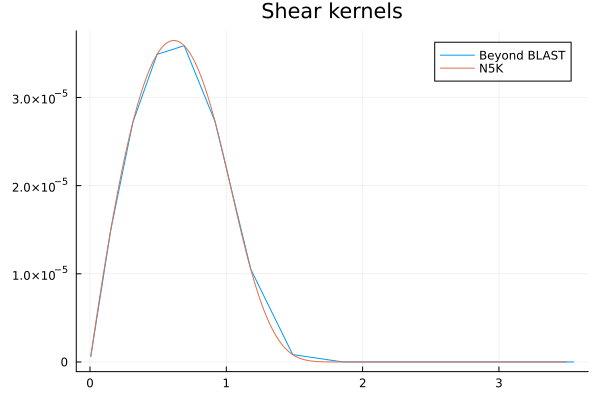

In [ ]:
bin = 4

p4 = plot(bgrid.z_range, ShearKernels.Kernel[bin,:], label="Beyond BLAST", title = "Shear kernels")
plot!(p4, W["z_sh"], W["kernels_sh"][bin,:], label="N5K")
save_plot(p4, "shear_kernels")

In [ ]:
K_CC, K_CL, K_LL = blast_tutorials.compute_kernels(W, χ, R)
w_χ = Blast.simpson_weight_array(n_chi)
w_R = Blast.get_clencurt_weights_R_integration(2*nR+1)
pref_CC = Blast.get_ell_prefactor(GalKernels, GalKernels, ℓ)
pref_CL = Blast.get_ell_prefactor(ShearKernels, GalKernels, ℓ)
pref_LL = Blast.get_ell_prefactor(ShearKernels, ShearKernels, ℓ);

In [ ]:
clustering_Cℓ = Blast.compute_Cℓ(w_CC, K_CC, bg, w_χ, w_R, pref_CC)
shear_Cℓ = Blast.compute_Cℓ(w_LL, K_LL, bg, w_χ, w_R, pref_LL)
cross_Cℓ = Blast.compute_Cℓ(w_CL, K_CL, bg, w_χ, w_R, pref_CL);

In [ ]:
@benchmark Blast.compute_Cℓ(w_CC, K_CC, bg, w_χ, w_R, pref_CC)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  24.791 μs …  14.804 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     29.708 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   37.888 μs ± 172.639 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▁▇█▇▇▆▅▅▄▃▂▂ ▁                                               ▂
  ██████████████████▇▇▇▇▆▆▇▆▇▆▆▅▆▆▆▅▅▅▆▆▃▆▅▅▅▅▄▄▆▆▆▆▅▄▄▁▆▆▅▄▄▅ █
  24.8 μs       Histogram: log(frequency) by time       106 μs <

 Memory estimate: 17.38 KiB, allocs estimate: 4.

In [ ]:
dtype = Float64
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_linear_full.npy"))
Cℓ_CL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_linear_full.npy"))
Cℓ_LL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_linear_full.npy"))
Cℓ_CC_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_nl_full.npy"))
Cℓ_CL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_nl_full.npy"))
Cℓ_LL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_nl_full.npy"));

In [ ]:
final_clustering_Cℓ = clustering_Cℓ + Cℓ_CC_limb_nl - Cℓ_CC_limb
final_cross_Cℓ = cross_Cℓ + Cℓ_CL_limb_nl - Cℓ_CL_limb
final_shear_Cℓ = shear_Cℓ + Cℓ_LL_limb_nl - Cℓ_LL_limb;

In [206]:
# Load extended Limber for ℓ>200, but with different variable names
Cℓ_CC_limb_ext = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber+200_full.npy"))
Cℓ_CL_limb_ext = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber+200_full.npy"))
Cℓ_LL_limb_ext = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber+200_full.npy"))

# Concatenate with your computed results (keep originals for correction)
total_Cℓ_CC = cat(final_clustering_Cℓ, Cℓ_CC_limb_ext, dims=1)
total_Cℓ_CL = cat(final_cross_Cℓ, Cℓ_CL_limb_ext, dims=1)
total_Cℓ_LL = cat(final_shear_Cℓ, Cℓ_LL_limb_ext, dims=1);

In [207]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
counter = 1

for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end

ll_reshaped = zeros(dtype, length(ell), 5, 5)
counter = 1

for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end

gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1

for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [208]:
# Interpolating to go on the same n5k grid
elle = dtype.(reverse(chebpoints(100, 2, 2000)))
ℓ_min = 2
ℓ_max = 2000

interp_Cℓ_CC = zeros(dtype, length(ell), 10, 10)  # ← ell → elle
interp_Cℓ_CL = zeros(dtype, length(ell), 10, 5)
interp_Cℓ_LL = zeros(dtype, length(ell), 5, 5)

for i in 1:10
    for j in i:10
        interpol = chebinterp(reverse(total_Cℓ_CC[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CC[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
        interp_Cℓ_CC[:,j,i] = interp_Cℓ_CC[:,i,j]
    end
end

for i in 1:10
    for j in 1:5
        interpol = chebinterp(reverse(total_Cℓ_CL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CL[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
    end
end

for i in 1:5
    for j in i:5
        interpol = chebinterp(reverse(total_Cℓ_LL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_LL[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
        interp_Cℓ_LL[:,j,i] = interp_Cℓ_LL[:,i,j]
    end
end

Saved: run_20260515_161152/plots/Cℓ_gg_comparison.png


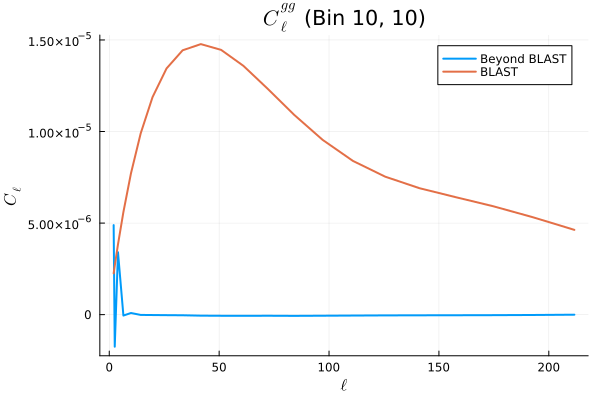

In [209]:
i = 10
j = 10
using LaTeXStrings
# Beyond BLAST uses your original ℓ (22 elements)
p_comparison = plot(ℓ, final_clustering_Cℓ[:, i, j], 
                    label="Beyond BLAST", title = latexstring("\$C_\\ell^{gg}\$ (Bin ", i, ", ", j, ")"),
                    xlabel=L"$\ell$", ylabel=L"$C_\ell$", linewidth=2)

# Load the original Limber data (22 elements) to match
Cℓ_CC_limb_orig = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_linear_full.npy"))

plot!(p_comparison, ℓ, Cℓ_CC_limb_orig[:, i, j], 
      label="BLAST", linewidth=2)

save_plot(p_comparison, "Cℓ_gg_comparison")

In [210]:
# Check if there's a missing constant
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 1, 1]) / maximum(final_clustering_Cℓ[:, 1, 1]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 2, 2]) / maximum(final_clustering_Cℓ[:, 2, 2]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 3, 3]) / maximum(final_clustering_Cℓ[:, 3, 3]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 4, 4]) / maximum(final_clustering_Cℓ[:, 4, 4]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 5, 5]) / maximum(final_clustering_Cℓ[:, 5, 5]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 6, 6]) / maximum(final_clustering_Cℓ[:, 6, 6]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 7, 7]) / maximum(final_clustering_Cℓ[:, 7, 7]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 8, 8]) / maximum(final_clustering_Cℓ[:, 8, 8]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 9, 9]) / maximum(final_clustering_Cℓ[:, 9, 9]))
println("Ratio (Limber / Beyond): ", 
        maximum(Cℓ_CC_limb_orig[:, 10, 10]) / maximum(final_clustering_Cℓ[:, 10, 10]))


Ratio (Limber / Beyond): 12.606669972009735
Ratio (Limber / Beyond): 29.9540508910077
Ratio (Limber / Beyond): 3.5643168310147377
Ratio (Limber / Beyond): 5.696196830041371
Ratio (Limber / Beyond): 97.29683951454504
Ratio (Limber / Beyond): 21.83306138096361
Ratio (Limber / Beyond): 8.093278389778526
Ratio (Limber / Beyond): 2.9665316590729836
Ratio (Limber / Beyond): 16.15348484880309
Ratio (Limber / Beyond): 3.0211309994071494


Saved: run_20260515_161152/plots/Cℓ_gg_linear_scale.png


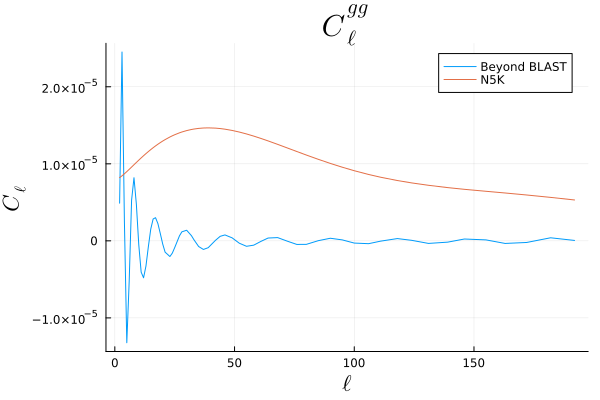

In [211]:
i = 10
j = 10
nl = 60 #set this to 103 to see up to ℓ=2000.
p5 = plot(ell[1:nl], interp_Cℓ_CC[1:nl,i,j], label="Beyond BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(p5, ell[1:nl], gg_reshaped[1:nl,i,j], label = "N5K")
save_plot(p5, "Cℓ_gg_linear_scale")

Saved: run_20260515_161152/plots/Cℓ_gg_ell_scaling.png


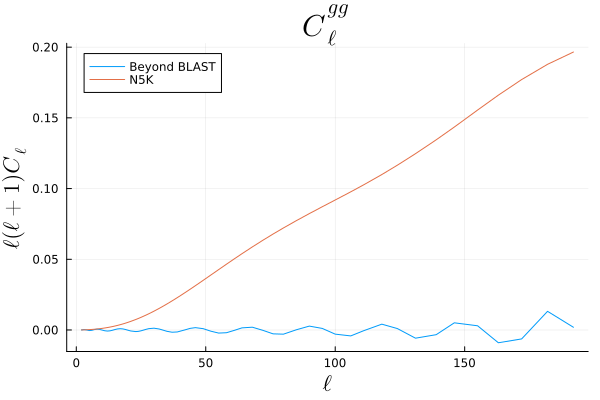

In [212]:
i = 10
j = 10
nl = 60 #set this to 103 to see up to ℓ=2000.
p6 = plot(ell[1:nl], interp_Cℓ_CC[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="Beyond BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(p6, ell[1:nl], gg_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p6, "Cℓ_gg_ell_scaling")

Saved: run_20260515_161152/plots/Cℓ_gs_linear_scale.png


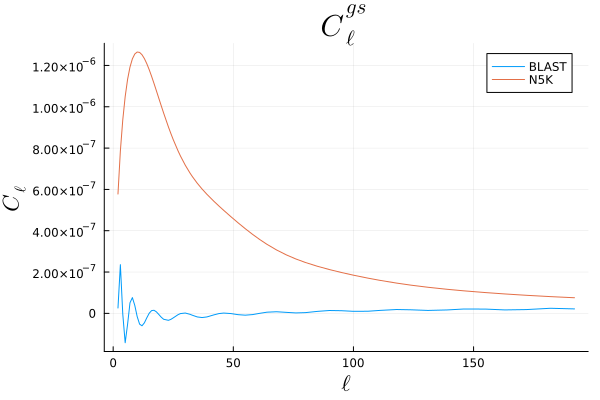

In [213]:
i = 1
j = 2
nl = 60 #set this to 103 to see up to ℓ=2000.
p7 = plot(ell[1:nl], interp_Cℓ_CL[1:nl,i,j], label="BLAST", title = L"$C_\ell^{gs}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gl_reshaped[1:nl,i,j], label = "N5K")
save_plot(p7, "Cℓ_gs_linear_scale")

Saved: run_20260515_161152/plots/Cℓ_gs_ell_scaling.png


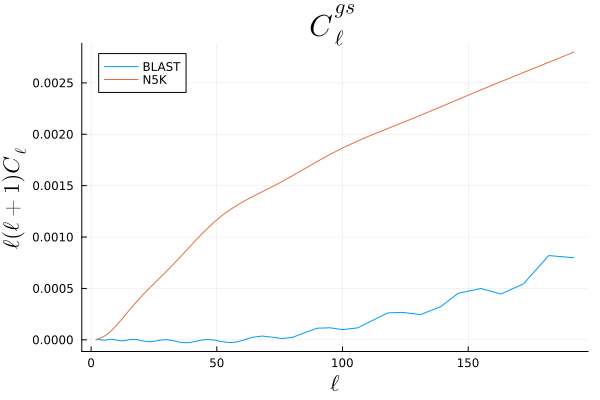

In [214]:
i = 1
j = 2
nl = 60 #set this to 103 to see up to ℓ=2000.
p8 = plot(ell[1:nl], interp_Cℓ_CL[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="BLAST", title = L"$C_\ell^{gs}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gl_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p8, "Cℓ_gs_ell_scaling")

Saved: run_20260515_161152/plots/Cℓ_ss_linear_scale.png


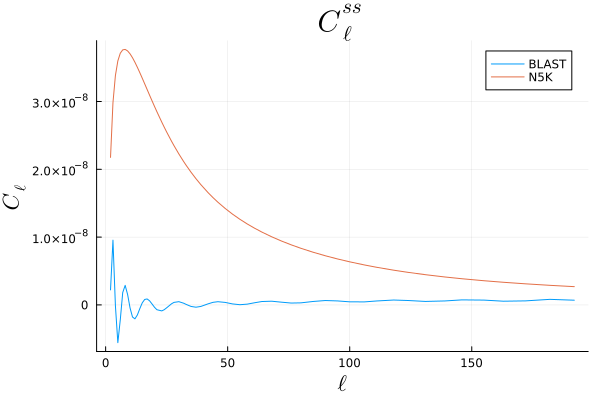

In [215]:
i = 3
j = 3
nl = 60 #set this to 103 to see up to ℓ=2000.
p9 = plot(ell[1:nl], interp_Cℓ_LL[1:nl,i,j], label="BLAST", title = L"$C_\ell^{ss}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(ell[1:nl], ll_reshaped[1:nl,i,j], label = "N5K")
save_plot(p9, "Cℓ_ss_linear_scale")

Saved: run_20260515_161152/plots/Cℓ_ss_ell_scaling.png


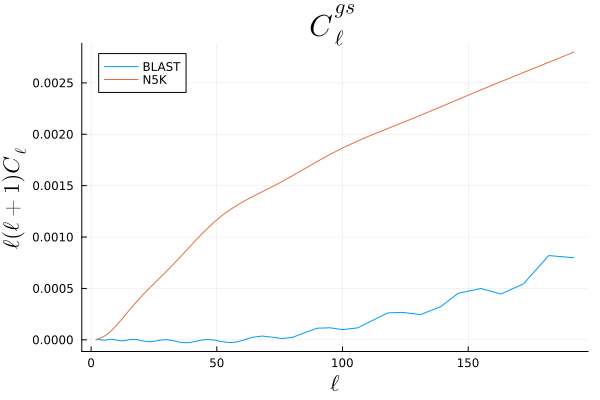

In [216]:
i = 3
j = 3
nl = 60 #set this to 103 to see up to ℓ=2000.
p10 = plot(ell[1:nl], interp_Cℓ_LL[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="BLAST", title = L"$C_\ell^{aa}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(ell[1:nl], ll_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p8, "Cℓ_ss_ell_scaling")

In [217]:
using NPZ

# After all computations, save everything
npzwrite(joinpath(output_dir, "results.npz"), Dict(
    "T_LL" => T_LL,
    "T_CL" => T_CL,
    "T_CC" => T_CC,
    "w_LL" => w_LL,
    "w_CL" => w_CL,
    "w_CC" => w_CC,
    "clustering_Cℓ" => clustering_Cℓ,
    "shear_Cℓ" => shear_Cℓ,
    "cross_Cℓ" => cross_Cℓ,
    "k" => k,
    "z" => z,
    "Pklin" => Pklin,
    "Pknonlin" => Pknonlin
))